5th notebook. Phylogenetic divergence correlations

In [1]:
import pandas as pd
from skbio import DistanceMatrix
from skbio.stats.distance import mantel
from qiime2 import Artifact
from qiime2.plugins.taxa.methods import filter_table
from qiime2.plugins.diversity_lib.methods import weighted_unifrac
import rpy2, os
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
datapath = '../data'
bombusMeta =pd.read_csv(os.path.join(datapath, 'BombusMetadata.tsv'), sep = '\t', index_col=0)

# Calculate correlations between genus-specific B-diversity and host phylogeny

## Setup

read feature tables, rooted tree 

In [2]:
level6 = pd.read_csv(os.path.join(datapath, 'table', 'genus_table.tsv'), index_col=0, sep = '\t').transpose()
mt = Artifact.load(os.path.join(datapath, 'qiime/mt.qza'))
taxa = pd.read_csv(os.path.join(datapath, 'table', 'ensemble_taxa.tsv'), index_col=0, sep = '\t')
rooted_tree=Artifact.load(os.path.join(datapath,'qiime/rooted_tree.qza'))

Only want to run testing on genera found in >10% of samples, pull them out

In [3]:
#found in 10%
withstrains = set(list((level6 >0).sum()[(level6 >0).sum() > level6.shape[0]*.1].index))
#genus
withstrains = [x for x in withstrains if 'g__' in x]
fullnames = withstrains.copy()
#shortname
withstrains = list(map(lambda x: x.split('__')[-1], withstrains))


calculate weighted unifrac for taxa-specific fractions of the microbiome

In [4]:
def printline(x):
    cols = taxa.loc[x].dropna().index
    return ';'.join([str.lower(c[0]) +'__' +taxa.loc[x, c] for c in cols])
prefixes = pd.DataFrame.from_dict({x: printline(x) for x in taxa.index}, orient = 'index',
                       columns = ['fullname'])
allcol = set(mt.view(pd.DataFrame).columns)
tables = {withstrains[i]: mt.view(pd.DataFrame)[list(allcol.intersection(\
         set(prefixes[prefixes['fullname'].str.startswith(fullnames[i])].index)))] for i in range(len(fullnames))}
tables = {c: tables[c].loc[tables[c][tables[c].sum(axis=1) > 0].index] for c in tables}

tables = {c: Artifact.import_data('FeatureTable[Frequency]', tables[c]) for c in tables}

# weighted unifrac 
wus = {c: weighted_unifrac(tables[c],
        phylogeny = rooted_tree) for \
      c in tables}
wus = { c: wus[c].distance_matrix.view(DistanceMatrix) for c in wus}

Running external command line application. This may print messages to stdout and/or stderr.
The command being run is below. This command cannot be manually re-run as it will depend on temporary files that no longer exist.

Command:

ssu -i /var/folders/_p/0rhlx8c56pgffwnwkjz824s80000gn/T/qiime2/markyoung/data/3eaf6128-5875-47fb-87b5-6f35059e0a21/data/feature-table.biom -t /var/folders/_p/0rhlx8c56pgffwnwkjz824s80000gn/T/qiime2/markyoung/data/35876f5c-5417-4221-bf1a-99b079937b5e/data/tree.nwk -m weighted_unnormalized -o /var/folders/_p/0rhlx8c56pgffwnwkjz824s80000gn/T/qiime2/markyoung/processes/22176-1754590358.694774@markyoung/tmp/q2-OutPath-rgwnzmyu

Running external command line application. This may print messages to stdout and/or stderr.
The command being run is below. This command cannot be manually re-run as it will depend on temporary files that no longer exist.

Command:

ssu -i /var/folders/_p/0rhlx8c56pgffwnwkjz824s80000gn/T/qiime2/markyoung/data/7d0b2055-d718-42bc-a254-0a5c9

read in the host data

In [5]:
dm_host =pd.read_csv( '../data/dm/dm_host.tsv', index_col=0, sep = '\t')
dm_host = DistanceMatrix(dm_host[dm_host.index], ids = dm_host.index)

dm_sp =pd.read_csv( '../data/dm/dm_host.tsv', index_col=0, sep = '\t')
sp_samps = {}
for s in bombusMeta['species'].unique():
    sp_samps[bombusMeta[bombusMeta['species'] == s].index[0]] = s
dm_sp =dm_sp.loc[sp_samps.keys(), sp_samps.keys()].rename(index = sp_samps, columns = sp_samps)

## test for correlations

pos corr = OTU similarity proportional to host phylogenetic similarity

**1. mantel tests for spearman correlation**

In [6]:
mantel_corrs = {c: mantel(wus[c], dm_host, strict=False) for c \
                in wus}
mantel_corrs = pd.DataFrame.from_dict(mantel_corrs, orient = 'index', 
                      columns = ['corr', 'p', 'n_samples']).sort_values(by='p')
mantel_corrs.dropna(inplace =True)
from statsmodels.stats.multitest import multipletests

mantel_corrs['fdr'] = multipletests(mantel_corrs['p'], method='fdr_bh')[1]


/Users/markyoung/miniforge3/envs/bombus/lib/python3.10/site-packages/skbio/stats/distance/_mantel.py:364: ConstantInputWarning: All values in data are exactly equal; results may not be reliable.
  warnings.warn(ConstantInputWarning())


In [8]:
mantel_corrs[mantel_corrs['fdr']<0.05]

,corr,p,n_samples,fdr
Schmidhempelia,0.157962,0.001,584,0.003750
Bombiscardovia,0.307811,0.001,355,0.003750
gbxid5846,0.678599,0.001,69,0.003750
Gilliamella,0.430180,0.001,617,0.003750
Fructobacillus,0.202893,0.001,344,0.003750
GWA2-37-10,0.125969,0.001,453,0.003750
Lactobacillus,0.224559,0.001,262,0.003750
Bifidobacterium,0.357828,0.001,254,0.003750
Entomomonas,0.160097,0.002,220,0.006667
Saccharibacter,0.093977,0.005,149,0.013636


### re-test with stratification by collection site 
- requires R package vegan

write data

In [9]:
if not os.path.isdir('../data/table/mantel'):
    os.mkdir('../data/table/mantel')
nosite = bombusMeta[bombusMeta['site_collapsed'].str.contains('No_Site')].index
for c in wus:
    temp = wus[c].to_data_frame().copy()
    temp.columns = ['x' + x for x in temp.columns]
    temp.drop(list(set(temp.index).intersection(set(nosite))), inplace=True )
    temp.index = ['x' + x for x in temp.index]
    
    temp.to_csv('../data/table/mantel/'+c+'.tsv', sep ='\t')

make index names in the host dm R-safe

In [10]:
dm_host = dm_host.to_data_frame()
dm_host.columns = ['x' + x for x in dm_host.columns]
dm_host.index = ['x' + x for x in dm_host.index]

Read in metadata, get site strata

In [11]:
bombusMeta = pd.read_csv('../data/BombusMetadata.tsv', sep='\t',
                        index_col=0)
strata = bombusMeta['site_year']
strata.index = ['x' + x for x in strata.index]

Read into R, calculate, write

In [12]:
%load_ext rpy2.ipython

In [13]:
if not os.path.isdir('../data/table/mantel_results'):
    os.mkdir('../data/table/mantel_results')

In [14]:
%%R -i dm_host,strata

library(vegan)

for (c in list.files(path = "../data/table/mantel")){
    dm <- read.table(paste0("../data/table/mantel/", c))
    res <- mantel(dm, dm_host[rownames(dm), colnames(dm)], strata = strata[rownames(dm)])
    sink(paste0('../data/table/mantel_results/', c))
    print(res$statistic)
    print(res$signif)
    sink()    
}


R[write to console]: Loading required package: permute

R[write to console]: Loading required package: lattice

R[write to console]: This is vegan 2.6-8



11 significant, after stratification and FDR correction

In [15]:
pms = pd.concat([pd.read_csv(os.path.join('../data/table/mantel_results', x), sep =' ',
    header = None)[[1]].transpose().rename(index = {1: x.split('.tsv')[0]},
    columns = {0: 'r', 1:'p'}) for x in os.listdir('../data/table/mantel_results') if \
          x.endswith('tsv')])
pms.dropna(inplace=True)
pms['fdrbh'] = sm.stats.multipletests(pms['p'],
                       method = 'fdr_bh', is_sorted=False,
                       returnsorted=False, alpha=0.1)[1]
pms.sort_values(by ='p')

,r,p,fdrbh
Saccharibacter,0.091237,0.001,0.003333
gbxid5846,0.674623,0.001,0.003333
Fructobacillus,0.201529,0.001,0.003333
Gilliamella,0.428694,0.001,0.003333
Bombiscardovia,0.307723,0.001,0.003333
Asaia,0.253693,0.001,0.003333
Bifidobacterium,0.354312,0.001,0.003333
Lactobacillus,0.220911,0.001,0.003333
Schmidhempelia,0.157312,0.001,0.003333
Entomomonas,0.160098,0.002,0.006000


In [16]:
pms[pms['fdrbh'] < 0.05].sort_values(by='r', ascending=False)

,r,p,fdrbh
gbxid5846,0.674623,0.001,0.003333
Gilliamella,0.428694,0.001,0.003333
Bifidobacterium,0.354312,0.001,0.003333
Bombiscardovia,0.307723,0.001,0.003333
Asaia,0.253693,0.001,0.003333
Lactobacillus,0.220911,0.001,0.003333
Fructobacillus,0.201529,0.001,0.003333
Entomomonas,0.160098,0.002,0.006000
Schmidhempelia,0.157312,0.001,0.003333
Saccharibacter,0.091237,0.001,0.003333


## 2 way plot

In [17]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform
from skbio.stats.ordination import pcoa

linkage_matrix = sch.linkage(squareform(dm_sp), method='average')
optimal_order = sch.leaves_list(sch.optimal_leaf_ordering(linkage_matrix, squareform(dm_sp)))
optimal_order = dm_sp.iloc[optimal_order].index

species_colors = pcoa(dm_sp).samples.set_index(dm_sp.index)[['PC1']]
import matplotlib.pyplot as plt
import numpy as np

norm = plt.Normalize(species_colors['PC1'].min(), species_colors['PC1'].max())
colormap = plt.cm.Spectral(norm(species_colors['PC1']))
species_colormap =dict(zip(species_colors.index, colormap))


alltables = []
for t in pms[pms['fdrbh'] < 0.05].index:

    test = tables[t].view(pd.DataFrame)
    missing_ids = [id for id in bombusMeta.index if id not in test.index]
    test = pd.concat([test, pd.DataFrame(np.nan,index=missing_ids, columns=test.columns)]).fillna(0)
    test = test.join(bombusMeta[['species']]).groupby('species').mean()
    test = test.loc[optimal_order]
    test_dm = np.abs((1- test.dropna(axis=0).corr(method ='pearson'))/2) #abs incase fp error 
    test_link = sch.linkage(squareform(test_dm), method='average')
    test_order =sch.leaves_list(sch.optimal_leaf_ordering(test_link, squareform(test_dm)))
    alltables.append(test[test_dm.columns[test_order]])
alltables = pd.concat([x.T for x in alltables]).T

In [18]:
pms.join(pd.DataFrame.from_dict({x: (tables[x].view(pd.DataFrame) > 0).sum(axis=1).mean() for x in tables}, 
                orient='index', columns = ['mean_strains']).sort_values(by='mean_strains', ascending=False))

,r,p,fdrbh,mean_strains
Saccharibacter,0.091237,0.001,0.003333,1.677852
Erwinia,0.009112,0.853,0.988929,1.649425
Spiroplasma,0.140737,0.056,0.135000,1.000000
Schmidhempelia,0.157312,0.001,0.003333,1.186644
Pantoea,0.144960,0.108,0.216000,2.844595
Stenotrophomonas,-0.033328,0.923,0.988929,1.011050
Rosenbergiella,0.022024,0.908,0.988929,1.645833
Acinetobacter,-0.059650,0.994,0.994000,1.495192
Neokomagataea,-0.098374,0.980,0.994000,1.234783
Cellulomonas,0.100813,0.694,0.905217,1.000000


In [23]:
pms.join(pd.DataFrame.from_dict({x: tables[x].view(pd.DataFrame).shape[1] for x in tables}, 
                orient='index', columns = ['ASVs'])).join(\
        pd.DataFrame.from_dict({x: tables[x].view(pd.DataFrame).shape[0] for x in tables}, 
                orient='index', columns = ['Samples'])).join(pd.DataFrame.from_dict({x: (tables[x].view(pd.DataFrame) > 0).sum(axis=1).mean() for x in tables}, 
                orient='index', columns = ['mean_strains']).sort_values(by='mean_strains',
 ascending=False))[['ASVs', 'Samples', 'mean_strains', 'r', 'p', 'fdrbh']].sort_values(by = 'r', ascending=False)

,ASVs,Samples,mean_strains,r,p,fdrbh
gbxid5846,5,69,1.043478,0.674623,0.001,0.003333
Gilliamella,65,617,2.361426,0.428694,0.001,0.003333
Bifidobacterium,27,254,1.610236,0.354312,0.001,0.003333
Bombiscardovia,8,355,1.016901,0.307723,0.001,0.003333
Asaia,8,73,1.150685,0.253693,0.001,0.003333
Lactobacillus,19,262,1.213740,0.220911,0.001,0.003333
Fructobacillus,30,344,1.825581,0.201529,0.001,0.003333
Entomomonas,18,220,1.304545,0.160098,0.002,0.006000
Schmidhempelia,41,584,1.186644,0.157312,0.001,0.003333
Pantoea,35,148,2.844595,0.144960,0.108,0.216000


/Users/markyoung/miniforge3/envs/bombus/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:146: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.0005013122858650158 and the largest is 0.010178122107513078.
  warn(
/Users/markyoung/miniforge3/envs/bombus/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:146: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for

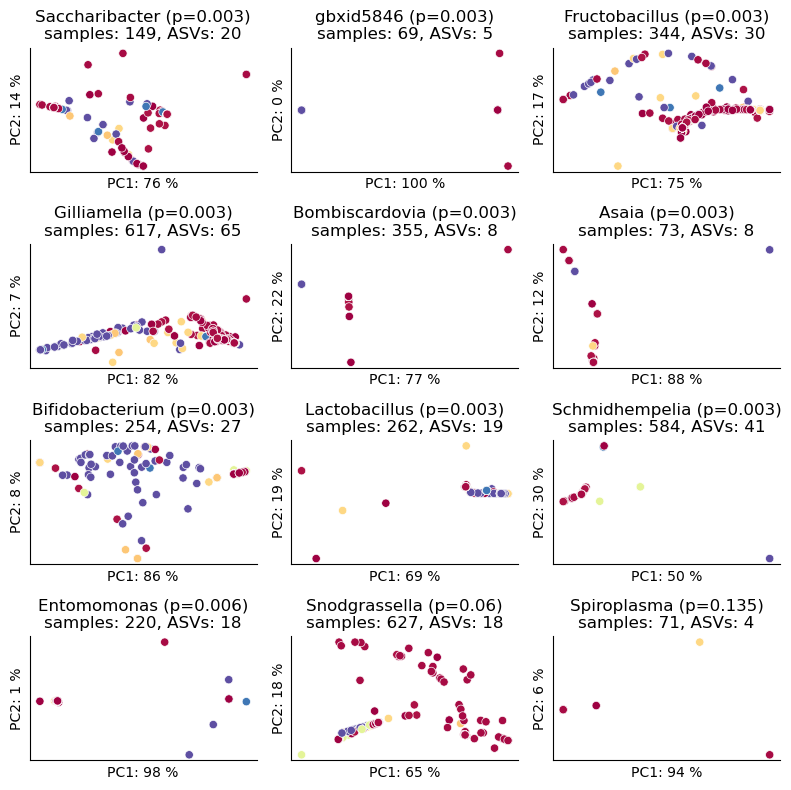

In [24]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

pms = pms.sort_values(by = 'p')
fig, ax = plt.subplots(4,3, figsize = (8, 8))
for i in range(12):
    y = i % 3
    x = i // 3

    test = pcoa(wus[pms.index[i]].data)
    test.samples.index = tables[pms.index[i]].view(pd.DataFrame).index
    test.samples = test.samples[['PC1', 'PC2']].join(bombusMeta['species'])
    sns.scatterplot(data = test.samples, x = 'PC1', y = 'PC2', hue ='species',
                    palette = species_colormap, hue_order = species_colors.sort_values(by = 'PC1').index,
                    ax = ax[x,y], legend = False)


    
    
    ax[x,y].set_title(pms.index[i] + ' (p=' + str(round(pms.loc[pms.index[i], 'fdrbh'], 3))+ ')'\
                       + '\nsamples: ' + str(test.samples.shape[0]) + ', ASVs: ' + str(tables[pms.index[i]].view(pd.DataFrame).shape[1]))
    ax[x,y].set_xticks([])
    ax[x,y].set_yticks([])
    ax[x,y].set_xlabel('PC1: ' + str(round( test.proportion_explained['PC1'] * 100) ) + ' %')
    ax[x,y].set_ylabel('PC2: ' + str(round(test.proportion_explained['PC2'] * 100) ) + ' %')
sns.despine()
plt.tight_layout()
fig.savefig('figs/ASV_PCoA.pdf',
               format = 'pdf', transparent = True, bbox_inches='tight')

/Users/markyoung/miniforge3/envs/bombus/lib/python3.10/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:146: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -8.819026080463656e-07 and the largest is 0.012639913247927723.
  warn(


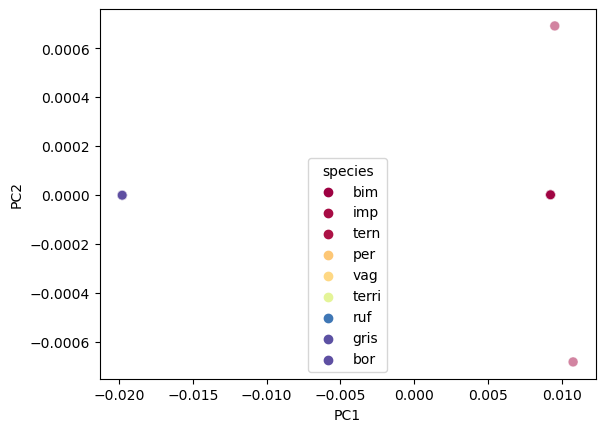

In [25]:
from skbio.stats.ordination import pcoa
fig, ax = plt.subplots()
test = pcoa(wus['gbxid5846'].data)
test.samples.index = tables['gbxid5846'].view(pd.DataFrame).index
test.samples = test.samples[['PC1', 'PC2']].join(bombusMeta['species'])
sns.scatterplot(data = test.samples, x = 'PC1', y = 'PC2', hue ='species',
                 palette = species_colormap, hue_order = species_colors.sort_values(by = 'PC1').index,
                 s=50, alpha = 0.5)
fig.savefig('figs/random_pcoa_with_legend.pdf',
               format = 'pdf', transparent = True, bbox_inches='tight')



# Barplot of OTU reulative abundances

**calculate cumulative sum of average relative abundances of OTUs**

In [28]:
tables = {c: tables[c].filtered_table.view(pd.DataFrame) for c in tables}
tables = pd.concat([(tables[x].transpose() /tables[x].sum(axis=1)\
            ).dropna().mean(axis=1).sort_values(ascending=False\
    ).reset_index().drop(columns='index').transpose().rename({0:x}) for \
          x in tables])
tables = tables.sort_values(by = 0, ascending=False).fillna(0)
tables = tables.transpose().cumsum().transpose()
tables = tables.reset_index().reset_index()

AttributeError: 'Artifact' object has no attribute 'filtered_table'

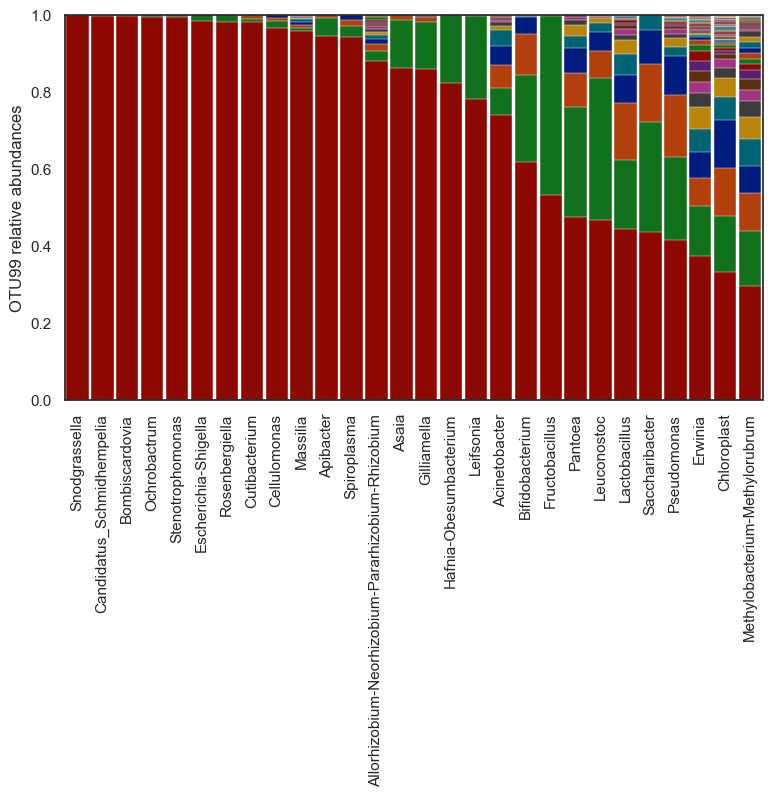

In [71]:
sns.set(style = 'white', palette = 'dark')
fig, ax = plt.subplots(figsize = (9, 5))
for i in np.arange(53, -1, -1):
    plt.bar(x = tables['level_0'], height = tables[i], 
           linewidth=0.3, alpha = 1, width=.9)
plt.xticks(tables['level_0'], labels = tables['index'], rotation = 90)
plt.xlim(-.5, 27.5)
plt.ylim(0,1)
plt.ylabel('OTU99 relative abundances')
plt.show()
fig.savefig('figs/OTU_barplot.pdf',
               format = 'pdf', transparent = True, bbox_inches='tight')

# ball and stick plots

In [5]:
tables = {withstrains[i]: mt.view(pd.DataFrame)[list(allcol.intersection(\
         set(prefixes[prefixes['fullname'].str.startswith(fullnames[i])].index)))] for i in range(len(fullnames))}
tables = {c: tables[c].loc[tables[c][tables[c].sum(axis=1) > 0].index] for c in tables}

/var/folders/_p/0rhlx8c56pgffwnwkjz824s80000gn/T/ipykernel_91898/103207507.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_species))  # Get a colormap with enough colors


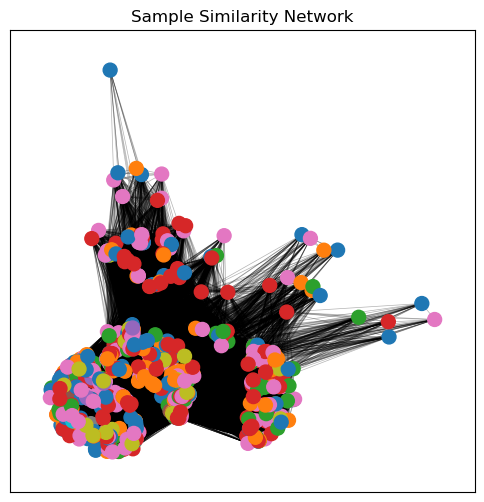

In [111]:
similarity_matrix = np.array((tables['Gilliamella'] > 0).astype(int).dot(tables['Gilliamella'].T > 0))
to_species = bombusMeta.loc[tables['Gilliamella'].index].reset_index()['species']
unique_species = to_species.unique()
colors = plt.cm.get_cmap('tab10', len(unique_species))  # Get a colormap with enough colors
species_color_map = {species: colors(i) for i, species in enumerate(unique_species)}
node_colors = [species_color_map[species] for species in to_species]


import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


num_samples = similarity_matrix.shape[0]

# Create graph
G = nx.Graph()
for i in range(num_samples):
    for j in range(i + 1, num_samples):
        if similarity_matrix[i, j] > 0:
            G.add_edge(i, j, weight=similarity_matrix[i, j])

# Compute positions using spring layout (edge weight as inverse distance)
pos = nx.spring_layout(G, weight='weight')

# Draw nodes
plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=100)

# Draw edges with thickness proportional to shared strains
edges = G.edges(data=True)
nx.draw_networkx_edges(
    G, pos, edgelist=[(u, v) for u, v, d in edges],
    width=[d['weight'] / 2 for _, _, d in edges], alpha=0.3
)

# Draw labels

plt.title("Sample Similarity Network")
plt.show()


# Tree with heatmap

In [29]:
bombusMeta['species'].unique()
tofullname = {'imp': 'B._impatiens', 'vag': 'B._vagans',
    'bor': 'B._borealis', 'bim': 'B._bimaculatus', 
    'ruf': 'B._rufocinctus', 'tern': 'B._ternarius', 'per': 'B._perplexus',
    'terri': 'B._terricola', 'gris': 'B._griseocollis'}


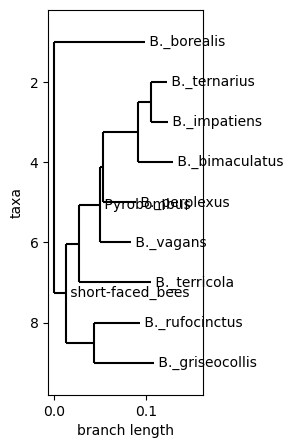

In [31]:
from Bio import Phylo

tree = Phylo.read('../data/tree', 'newick')
filtered_tree = tree
for clade in tree.get_terminals():
    if clade.name not in tofullname.values():
        filtered_tree.prune(clade)
fig, ax = plt.subplots(figsize=(2, 5))

Phylo.draw(filtered_tree, axes = ax)

plt.show()
fig.savefig('figs/filtered_tree.pdf',
               format = 'pdf', transparent = True, bbox_inches='tight')


In [109]:
df = wus['Bombiscardovia'].to_data_frame()
df = df.reset_index().rename(columns = {'index': 's0'})
df = pd.melt(df, id_vars = ['s0'], var_name = 's1', value_name = 'weighted_unifrac')
df['species0'] = pd.merge(df, bombusMeta[['species']], left_on = 's0', right_index = True)['species'].replace(tofullname)
df['species1'] = pd.merge(df, bombusMeta[['species']], left_on = 's1', right_index = True)['species'].replace(tofullname)
df['comparison'] = df.apply(lambda x: "_".join(sorted([x['species0'], x['species1']])), axis = 1)
pd.DataFrame(df.groupby('comparison')['weighted_unifrac'].mean())


,weighted_unifrac
comparison,
B._bimaculatus_B._bimaculatus,0.000212
B._bimaculatus_B._borealis,0.004619
B._bimaculatus_B._impatiens,0.000522
B._bimaculatus_B._perplexus,0.002739
B._bimaculatus_B._rufocinctus,0.000107
B._bimaculatus_B._sandersoni,0.000107
B._bimaculatus_B._ternarius,0.000140
B._bimaculatus_B._terricola,0.000107
B._bimaculatus_B._vagans,0.000107
